Figure 1C
(C) Degradation of specific targets results in differential magnitude of mis-splicing. Swarm plot represents the fold change in global mis-splicing (proportion of mis-spliced fragments versus aligned fragments) with maximum target degradation at 9 hours compared to 0nM dose (mean +/- SEM, n=3 biological replicates/condition, two-tailed unpaired Student’s t-test).

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random as rand

from natsort import os_sorted
from matplotlib.patches import Patch
from scipy.stats import sem


In [2]:
big_meta = pd.read_csv('../../data/dtag_experiments/metadata_anon.tsv',sep='\t')

big_meta.index = [i.split('_Aligned')[0] for i in big_meta['Sample basename'].values]

In [15]:
misproc_values = pd.read_csv('../../data/anon_data/misproc_df.tsv',sep='\t',header=None,index_col=0)

In [16]:
code_order = [
    'Gene1_True',
    'Gene1_False',
    'Gene2_True',
    'Gene2_False',
    'Gene3_True',
    'Gene3_False',
    'Gene4_True',
    'Gene4_False',
    'Gene5_True',
    'Gene5_False',
    'Gene6_True',
    'Gene6_False',
    'Gene7_True',
    'Gene7_False',
    'Gene8_True',
    'Gene8_False',
]

color_dict = {
    'Gene6':'tab:orange',
    'Gene2':'tab:brown',
    'Gene8':'tab:blue',
    'Gene5':'tab:cyan',
    'Gene7':'tab:pink',
    'Gene4':'tab:green',
    'Gene3':'tab:red',
    'Gene1':'tab:purple'
}


In [34]:
def plot_swarm(x_order,yval_df,ax):
    for i in range(len(x_order)):
        xvals = np.array([rand.uniform(-0.2,0.2) for i in range(0,3)]) + i
        ax.scatter(
            xvals, 
            yval_df.loc[yval_df['code'] == x_order[i],'misproc'],
            c=color_dict[x_order[i].split('_')[0]]
        )
        
def plot_ranges(x_order,mean_df,error_df,ax):
    for i in range(len(x_order)):
        ax.plot(
            [i-0.3,i+0.3], 
            [mean_df.loc[x_order[i],0]]*2,
            c='k'
        )
        ax.plot(
            [i,i],
            [
                mean_df.loc[x_order[i],0]+error_df.loc[x_order[i],0],
                mean_df.loc[x_order[i],0]-error_df.loc[x_order[i],0]
            ],
            c='k'
        )
        ax.plot(
            [i-0.1,i+0.1], 
            [mean_df.loc[x_order[i],0]+error_df.loc[x_order[i],0]]*2,
            c='k'
        )
        ax.plot(
            [i-0.1,i+0.1], 
            [mean_df.loc[x_order[i],0]-error_df.loc[x_order[i],0]]*2,
            c='k'
        )
        
def plot_swarm_all(big_filt,ax):
    misproc_df = pd.DataFrame(
        [
            misproc_values.loc[big_filt.index,1],
            big_filt['Target'] + '_' + [str(i==0) for i in big_filt['Dosage value']]
        ]
    ).transpose()
    misproc_df.columns = ['misproc','code']

    tmp=[]

    for code in code_order:
        ctrl_code = code.split('_')[0] + '_True'
        misproc_norm = misproc_df.loc[
            misproc_df['code'] == code,'misproc'
        ] / np.mean(misproc_df.loc[misproc_df['code'] == ctrl_code,'misproc'])
        tmp.append(pd.DataFrame([
            misproc_norm,
            misproc_df.loc[misproc_df['code'] == code,'code']
        ]))

    misproc_norm_df = pd.concat(tmp,axis=1).transpose()

    bar_vals = []
    error_vals = []
    for i in code_order:
        inds = misproc_norm_df[misproc_norm_df['code'] == i].index
        bar_vals.append(np.mean(misproc_norm_df.loc[inds,'misproc']))
        error_vals.append(sem(misproc_norm_df.loc[inds,'misproc']))

    bar_vals = pd.DataFrame(bar_vals)
    error_vals = pd.DataFrame(error_vals)

    bar_vals.index = code_order
    error_vals.index = code_order
    
    plot_ranges(code_order,bar_vals,error_vals,ax)
    plot_swarm(code_order,misproc_norm_df,ax)

In [19]:
xticks = list(range(len(code_order)))
xtick_labs = [
    'Gene1_Veh',
    'Gene1_dTAG',
    'Gene2_Veh',
    'Gene2_dTAG',
    'Gene3_Veh',
    'Gene3_dTAG',
    'Gene4_Veh',
    'Gene4_dTAG',
    'Gene5_Veh',
    'Gene5_dTAG',
    'Gene6_Veh',
    'Gene6_dTAG',
    'Gene7_Veh',
    'Gene7_dTAG',
    'Gene8_Veh',
    'Gene8_dTAG',
]

In [20]:
big_filt_6 = big_meta.loc[
    ((big_meta['Dosage value']==0) |
    (big_meta['Dosage value']>100)) &
    (big_meta['Time value'] == 6)
]

big_filt_9 = big_meta.loc[
    ((big_meta['Dosage value']==0) |
    (big_meta['Dosage value']>100)) &
    ((big_meta['Time value']>6) & (big_meta['Time value']<12))
]


big_filt_12 = big_meta.loc[
    ((big_meta['Dosage value']==0) |
    (big_meta['Dosage value']>100)) &
    (big_meta['Time value'] == 12)
]


(0.7, 2.5)

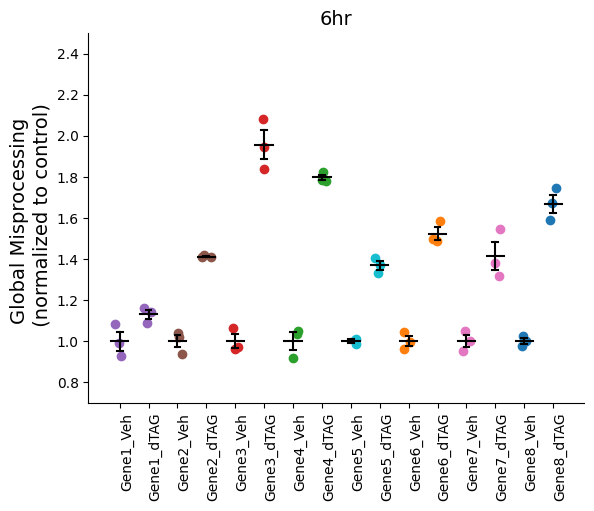

In [35]:
fig,ax = plt.subplots()

plot_swarm_all(big_filt_6,ax)

ax.set_ylabel('Global Misprocessing \n (normalized to control)', fontsize=14)
# ax.grid()

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labs,
                   fontsize=10,
                   rotation=90,
                   ha='right', 
                   rotation_mode='anchor')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('6hr', fontsize=14)
ax.set_ylim([0.7,2.5])

(0.7, 2.5)

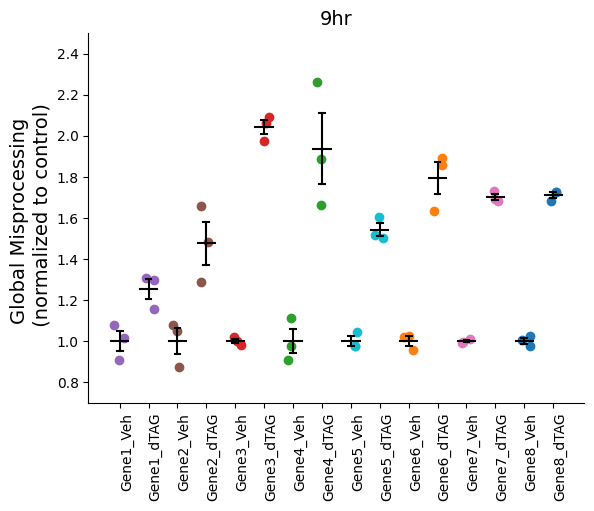

In [36]:
fig,ax = plt.subplots()

plot_swarm_all(big_filt_9,ax)

ax.set_ylabel('Global Misprocessing \n (normalized to control)', fontsize=14)
# ax.grid()

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labs,
                   fontsize=10,
                   rotation=90,
                   ha='right', 
                   rotation_mode='anchor')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('9hr', fontsize=14)
ax.set_ylim([0.7,2.5])

(0.7, 2.5)

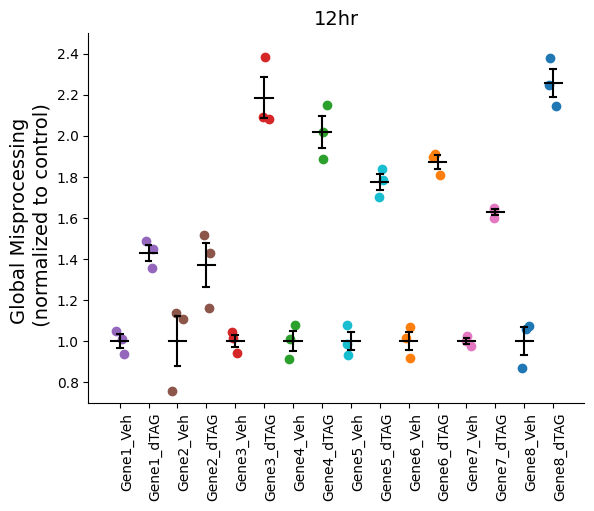

In [37]:
fig,ax = plt.subplots()

plot_swarm_all(big_filt_12,ax)

ax.set_ylabel('Global Misprocessing \n (normalized to control)', fontsize=14)
# ax.grid()

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labs,
                   fontsize=10,
                   rotation=90,
                   ha='right', 
                   rotation_mode='anchor')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('12hr', fontsize=14)
ax.set_ylim([0.7,2.5])

Figure 1D 
(D) Gene8 has a unique mis-splicing signature compared to other targets. Dimension reduction analysis of mis-splicing scores was used to identify target clusters, suggesting similar signatures of mis-splicing. Clustering is visually apparent with biologically relevant proteins clustering together.

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

from natsort import os_sorted
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


C:\Users\hobri\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
def flatten(regular_list):
    return [item for sublist in regular_list for item in sublist]

In [43]:
delta_df = pd.read_csv('../../data/dtag_experiments/1D_delta_df_anon.tsv',sep='\t',index_col=0)

inds = flatten([np.array([3,4,5])+i*6 for i in range(0,8)])

delta_df_filt = delta_df.iloc[:,inds]

In [44]:
color_dict = {
    'Gene6':'tab:orange',
    'Gene2':'tab:brown',
    'Gene8':'tab:blue',
    'Gene5':'tab:cyan',
    'Gene7':'tab:pink',
    'Gene4':'tab:green',
    'Gene3':'tab:red',
    'Gene1':'tab:purple'
}

legend_elements = [
    Patch(
        facecolor=color_dict[i],
        label=i
    ) for i in os_sorted(list(color_dict.keys()))    
]

In [397]:
x = StandardScaler().fit_transform(delta_df_filt.transpose())

pca = PCA(n_components=len(delta_df_filt.columns))

principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(
    data = principalComponents,
)

colors = [color_dict[i.split('_')[0]] for i in delta_df_filt.columns]
    
targets = ['_'.join([j[0],j[3]]) for j in [i.split('_') for i in delta_df_filt.columns]]


finalDf = pd.concat(
    [
        principalDf, 
        pd.Series(colors), 
        pd.Series(targets),
    ], axis = 1)


pca_var_dict = {
    principalDf.columns[i]:pca.explained_variance_ratio_[i] 
    for i in range(len(principalDf.columns))}

C:\Users\hobri\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


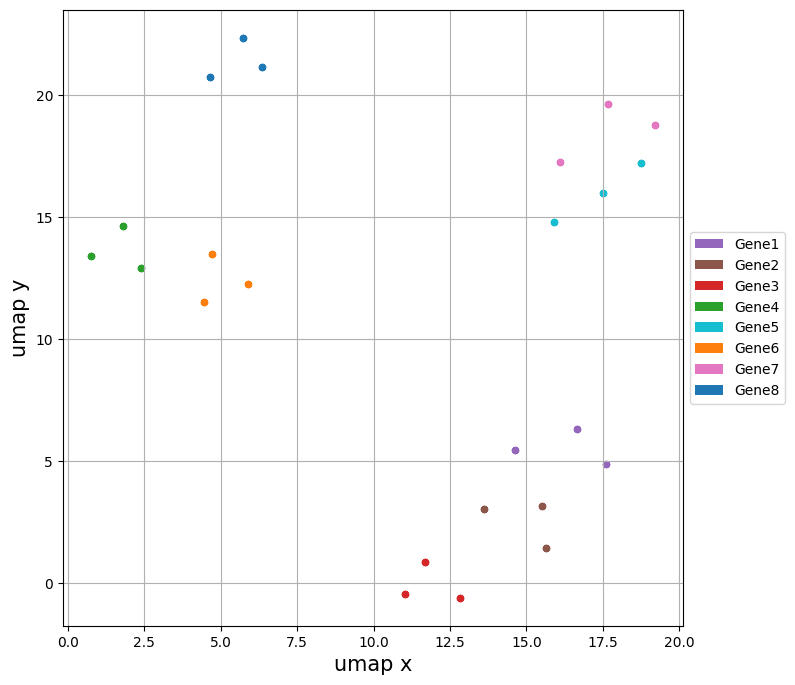

In [470]:
colors = [color_dict[i.split('_')[0]] for i in delta_df_filt.columns]
    
symbols = ['.']*len(delta_df_filt.columns)
targets = ['_'.join([j[0],j[3]]) for j in [i.split('_') for i in delta_df_filt.columns]]

randnum=int(rand.uniform(0,1)*1000)

umap_space_1 = umap.UMAP(
    n_neighbors=4,
    min_dist=1,
    spread=3,
    init='spectral',
    metric='cosine',
    random_state=randnum
).fit_transform(
    principalDf.iloc[:,:14]
)


umap_final_1 = pd.concat(
    [
        pd.DataFrame(umap_space_1),
        pd.Series(colors),
        pd.Series(symbols),
        pd.Series(targets)
    ],
    axis=1
)

umap_final_1.columns = [
    'umap x',
    'umap y',
    'color',
    'symbol',
    'target'
]

pc_x = 'umap x'
pc_y = 'umap y'

fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(pc_x, fontsize = 15)
ax.set_ylabel(pc_y, fontsize = 15)


for target in targets:
    indicesToKeep = umap_final_1.iloc[:,-1] == target
    color = umap_final_1.loc[indicesToKeep,'color'].values[0]
    symbol = umap_final_1.loc[indicesToKeep,'symbol'].values[0]
    ax.scatter(umap_final_1.loc[indicesToKeep, pc_x],
               umap_final_1.loc[indicesToKeep, pc_y],
               c = color,
               s = 75,
               marker=symbol,
              )



box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

plt.legend(handles = legend_elements,loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid()